## 미션1_“이 데이터는 믿을 만할까?”
결측·이상치·편향을 점검하고, 처리 기준을 제시한다.<br>
MedHouseValue가 0이거나 극단값인지, MedInc/HouseAge/AveRooms 등 주요 변수의 범위가 현실적인지 확
인한다.<br>
1940년 이전 건축 주택이 52로 코딩되는 이유를 이해하고, 분석에 미칠 영향을 검토한다.<br>
전처리 전·후가 어떻게 달라졌는지 한눈에 비교하는 표나 요약을 만든다.<br>
단위·해석 주의: MedHouseValue는 실제 달러 단위입니다. 1990년 명목가를 참고해 현실성을 평가하세요.<br>
📌 출제 의도 “이 값이 말이 되나?”를 먼저 묻고, 어떻게 처리했는지를 기록해 나중 해석에 근거를 남기는 연습입니
다

# 미션 1: “이 데이터는 믿을 만할까?” 데이터 검증 보고서

## 1. 개요 (Mission Objective)
본 분석의 목적은 캘리포니아 하우징 데이터셋의 신뢰성을 검토하고, 결측치 및 이상치를 처리하여 분석 가능한 상태의 정제된 데이터를 확보하는 것입니다.
> **핵심 질문:** "이 값이 말이 되는가?"를 먼저 묻고 처리 근거를 기록한다.

---

## 2. 결측치 및 변수 범위 점검 (Data Quality Check)

### 2.1 결측치(Missing Value) 현황 및 처리
- **현황:** `total_bedrooms` 열에서 **207건**의 결측치 확인.
- **처리:** 분석의 일관성을 위해 결측치가 포함된 행을 삭제(`dropna`) 처리함.

### 2.2 변수별 현실성 평가
| 변수명 | 현실성 점검 내용 | 처리 및 판단 |
| :--- | :--- | :--- |
| **MedHouseValue** | 1990년 명목가 기준, $500,001 상한선 존재. | 실제 달러 단위이며 상한선(Censored) 데이터임을 인지하고 분석함. |
| **MedInc** | 단위는 약 $1 = $10,000임 (예: 3.5 = $35,000). | 90년대 물가를 고려할 때 적절한 범위임. |
| **AveRooms** | 한 가구당 평균 방 개수가 10개를 초과하는 극단치 존재. | **10 미만**의 값만 유효 데이터로 간주하여 필터링함. |
| **HousingAge** | 주택 연령의 중앙값 분포 확인. | 아래 52세 코딩 이슈 확인 필요. |

---

## 3. 특정 수치(52)의 코딩 이유 분석
- **현상:** `housing_median_age` 변수에서 52년 이상 된 주택이 모두 **52**로 기록됨.
- **원인:** 데이터 수집 시 발생한 **상한 포화(Right-censoring)** 문제. 
- **영향:** 실제로는 60년, 100년 된 주택도 52로 표기되어 있으므로, 노후 주택의 특성이 왜곡될 수 있음. 분석 시 이를 범주형(52세 이상)으로 해석하거나 해당 데이터를 고려하여 모델링해야 함.

---

## 4. 전처리 전/후 비교 요약 (Summary Table)

주요 변수에 대해 `ave_rooms` 이상치 제거 전과 후의 사분위수 변화를 비교한 결과입니다.

| 구분 | median_house_value | median_income | housing_median_age | ave_rooms |
| :--- | :---: | :---: | :---: | :---: |
| **Before (0.5)** | 179,700.0 | 3.5348 | 29.0 | 5.2291 |
| **After (0.5)** | 180,400.0 | 3.5341 | 29.0 | **5.2132** |

- **해석:** 이상치 제거 후 `ave_rooms`의 평균적인 수치가 현실적으로 조정되었으며, 타 변수의 중앙값에는 큰 왜곡을 주지 않으면서 데이터의 정제도가 높아짐.

---

## 5. 최종 결론
1. 본 데이터셋은 **상한선(Censoring)**과 **이상치**가 존재하지만, 적절한 필터링을 통해 분석용 데이터로 충분히 활용 가능함.
2. 향후 모델링 시 `MedHouseValue`와 `HousingAge`의 상한값(500,001 및 52) 처리에 대한 추가 전략 수립이 필요함.

# 미션 2: “가격과 핵심 변수의 첫인상” 분석 보고서
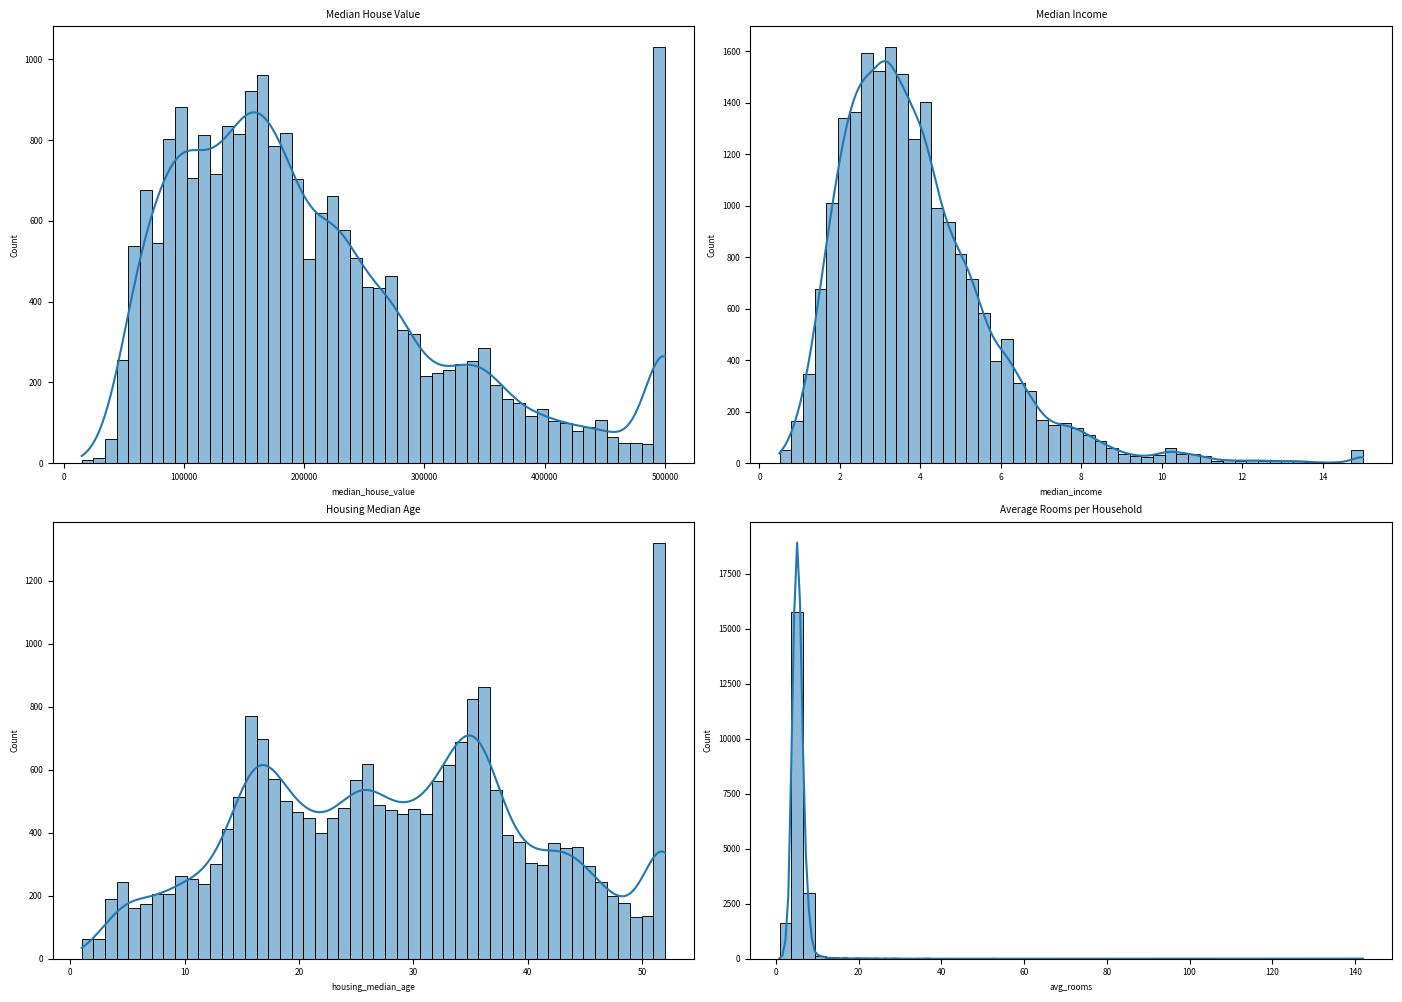

## 1. 개요 (Mission Objective)
본 단계에서는 주요 변수(`MedHouseValue`, `MedInc`, `HouseAge`, `AveRooms`)의 분포를 히스토그램과 KDE(커널 밀도 추정)를 통해 확인하고, 데이터의 왜도 및 이상치가 회귀 분석에 미치는 영향과 전처리 방향성을 도출합니다.

---

## 2. 주요 변수별 분포 분석 결과

### 2.1 Median House Value (목표 변수)
- **분포 특성:** 강한 **우측 꼬리(Right-skewed)** 형태를 보이며, 평균이 상단 값에 끌려 왜곡되어 있음.
- **특이 사항:** $500,001 지점에서 급격한 스파이크(상한선 처리)가 관찰됨.
- **분석 영향:** 선형 회귀 시 잔차의 비정상성 및 고가 주택에 대한 예측 한계 발생 가능.

### 2.2 Median Income (중위 소득)
- **분포 특성:** 전형적인 경제 변수의 분포로, 저소득 구간에 밀집되어 있고 고소득으로 갈수록 희소해지는 **우측으로 긴 꼬리**를 가짐.
- **분석 영향:** 비대칭성이 강하므로 로그 변환 등을 통한 정규화 검토가 필요함.

### 2.3 Housing Median Age (주택 연령)
- **분포 특성:** 1~52세까지 비교적 고르게 분포하나, **52세 지점에서 강한 수직 스파이크** 발생.
- **해석 주의:** 52는 실제 52년 된 집이 아니라 **1940년 이전 건축물을 하나로 묶은 코드**임.
- **분석 영향:** 연속형 변수처럼 보이지만 사실상 **연속+범주가 섞인 혼합 변수**로, 평균/분산 해석이 왜곡될 수 있음.

### 2.4 Average Rooms (평균 방 개수)
- **분포 특성:** 중심은 3~6개 사이에 밀집되어 있으나, 10~20개 이상의 **극단적 이상치**가 존재함.
- **원인:** 가구수(`households`)가 매우 작은 지역에서 총 방 개수(`total_rooms`)가 클 경우 발생하는 수학적 비율 변수의 전형적 이상치임.

---

## 3. 공간적/시간적 요인 검토

- **공간적 요인:** 캘리포니아 데이터 특성상 해안 vs 내륙, 북부 vs 남부 등 **Latitude/Longitude에 따른 공간적 편향**이 분포 왜곡의 상당 부분을 차지함.
- **시계열적 한계:** 본 데이터는 **1990년 Census** 기준이므로 현재 가격 수준과 직접 비교가 불가능함. 반드시 "1990년 당시 상대적 가격"을 기준으로 해석해야 함.

---

## 4. 종합 결론 및 전처리 제언
> **"단순 평균 기반 해석이나 변환 없는 회귀 분석은 부적합하다."**

1. **로그 변환 필수:** 비대칭 분포를 가진 목표 변수와 소득 변수에 대해 로그 변환을 통해 정규성을 확보해야 함.
2. **이상치 및 구간화:** `AveRooms`의 극단치를 제거하고, `HouseAge`와 같이 상한 처리가 된 변수는 구간화(Binning)나 더미 변수 분리를 통해 모델의 해석 가능성을 높여야 함.
3. **지리적 특성 활용:** 단순 수치 분석을 넘어 위도/경도 정보를 모델에 효과적으로 반영하는 것이 필수적임.

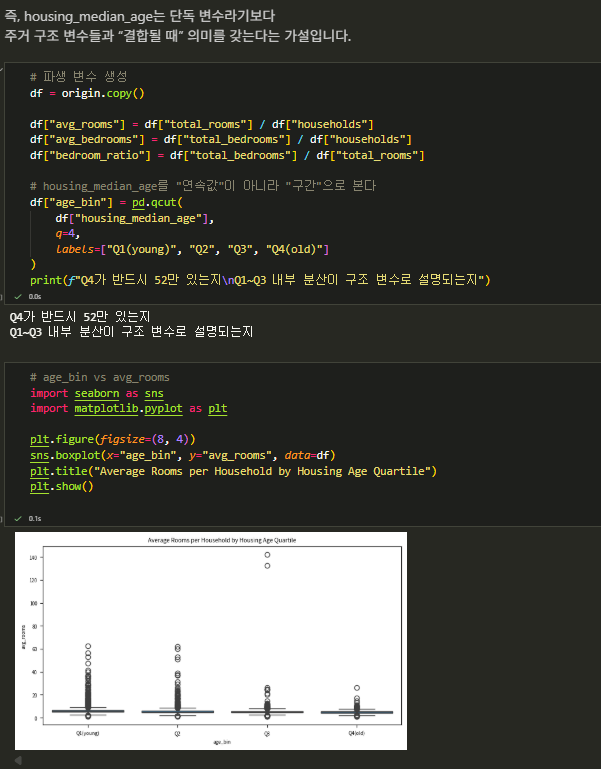<br>
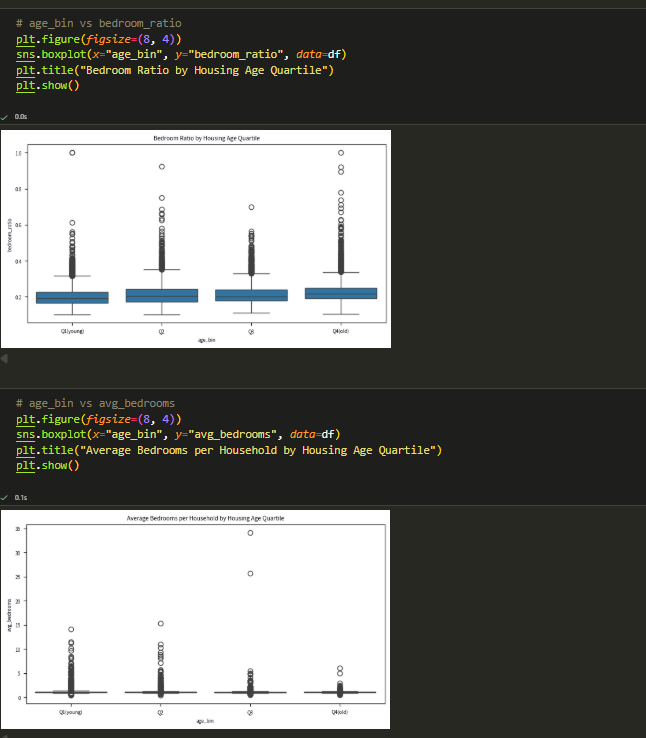

# [가설 검증] Housing Median Age의 분포 해석과 처리 전략

`housing_median_age` 변수가 주택 구조(`avg_rooms`) 및 지역적 특성과 어떤 관계를 갖느냐에 따라 세 가지 분석 경로를 설정할 수 있습니다.

---

## 🔍 경우 ①: 도시 구조의 역사적 변천 반영
**"시간의 흐름에 따른 주거 형태의 변화"**

* **현상:** `age`가 증가할수록 `avg_rooms`가 명확히 감소하는 경향을 보임.
* **해석:** 오래된 지역일수록 소형 주택 위주로 형성되어 있으며, 이는 도시 공학적 변천사를 반영함.
* **분석 가치:** `age`의 분산이 실제 도시 구조의 차이를 설명하므로, **의미 있는 독립 변수**로 활용 가능함.

---

## 🔍 경우 ②: 데이터 노이즈 및 행정적 한계
**"변수 단독의 설명력 부족"**

* **현상:** `age`와 주거 구조 변수 간의 유의미한 상관관계나 차이가 거의 발견되지 않음.
* **해석:** 데이터상의 분산이 실제 주거 특성이 아닌, 행정 구역 설정이나 코딩 과정에서 발생한 **단순 노이즈**일 가능성이 높음.
* **분석 가치:** * `housing_median_age` 단독 사용은 모델에 왜곡을 줄 위험이 있음.
    * 소득(`MedInc`)이나 지리적 위치와의 **상호작용(Interaction)** 변수 도입이 필수적임.

---

## 🔍 경우 ③: 역사적 단층과 데이터 상한 처리
**"1940년 이전 주택의 특수성"**

* **현상:** 전체 분포 중 상한값인 **Q4(52세)** 지점에서만 주거 구조가 급격하게 변화함.
* **해석:** "1940년 이전 건축"이라는 데이터 수집 기준이 일종의 **역사적 단층**으로 작용함.
* **분석 가치:** * 단순 연속형 변수로 취급하기보다, 상한 여부를 판별하는 **`age_is_capped` 이진 변수(Binary Variable)** 도입이 타당함.
    * 해당 그룹을 별도로 분리하여 분석할 때 모델의 해석력이 극대화됨.

---

> **💡 데이터 파트너의 조언:** > 현재 시각화된 히스토그램에서 **52세 지점의 스파이크**가 뚜렷하므로, **경우 ③**에 대한 가설을 먼저 검증해 보시는 것을 추천드립니다.



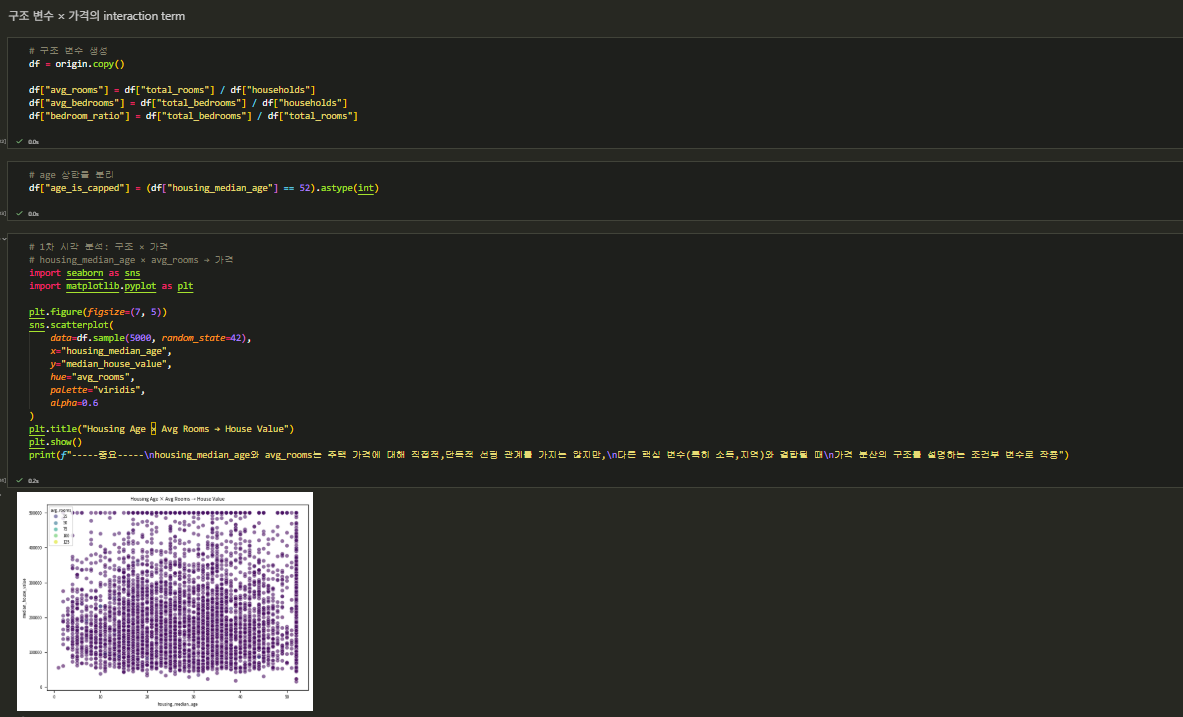<br> 
**중요**<br>
housing_median_age와 avg_rooms는 주택 가격에 대해 직접적,단독적 선형 관계를 가지는 않지만,<br>
다른 핵심 변수(특히 소득,지역)와 결합될 때<br>
가격 분산의 구조를 설명하는 조건부 변수로 작용<br>

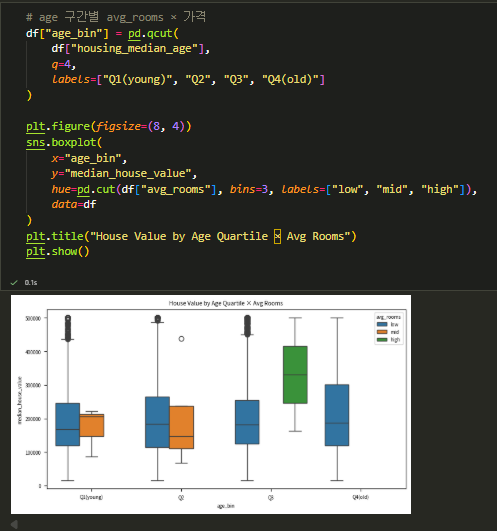
예상대로 방 수가 많은 주택의 주택 중위 가격이 높았음.<br>
또한, 최신형 주택일 때 방 수가 적은 박스플롯이 방 수가 적은 low가
mid보다 사분위수 구간이 더 낮은 쪽에 위치함에도 불구하고 mid와 달리 이상치가 발견된 것에 의문<br>

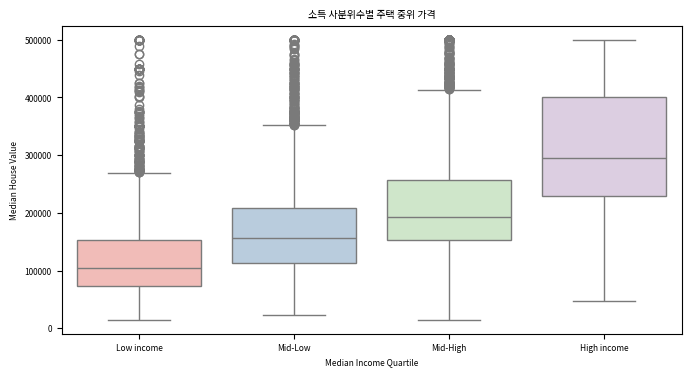
# 🏠 소득 대비 고가 주택 이상치(Outlier) 발생 원인 분석

저소득(Low income) 구간에서 소득 수준을 상회하는 고가 주택이 발견되는 현상의 원인과 영향력이 큰 변수를 순차적으로 분석합니다.

---

## 1. 근본적 전제: 소득과 구매력의 불일치
소득은 현재의 "현금 흐름(Who has more income)"을 나타낼 뿐, "자산의 총량(Who bought the most expensive house)"을 완벽히 대변하지 않습니다.
* **일부 고가 주택:** 증여, 상속 등을 통한 보유.
* **고자산 가구:** 은퇴자 등 소득은 낮으나 보유 자산이 많은 경우.
* **투자 목적:** 실거주 목적이 아닌 자산 증식용 보유.

> **📌 핵심 요약** > 소득은 "누가 돈을 많이 버는가"를 말해주지만, "누가 가장 비싼 집을 샀는가"를 항상 설명하지는 못합니다.

---

## 2. 현상의 주요 원인 (Ranking)

### 1순위: 입지(Location) 변수의 지배력 (가장 중요) 📍
저소득 구간 고가 이상치의 가장 강력한 원인입니다. 주민의 소득이 낮더라도 **토지의 희소성**과 **입지 프리미엄**이 가격을 결정합니다.
* **작동 메커니즘:** 해안 인접(NEAR OCEAN, NEAR BAY), 도심 핵심 지역, 개발 제한 구역 등.
* **특징:** 입지가 좋으면 거주자의 소득과 무관하게 지가가 상승합니다.

### 2순위: 주택 가격 상한 포화 효과 (Censoring) 📉
데이터 수집 시 설정된 상한선($500,001)이 착시 효과를 일으킵니다.
* **고소득 구간:** 진짜 고가 주택($1M 이상 등)들이 50만 불 상한선에 걸려 가격이 낮게 눌림.
* **저소득 구간:** 일부 고가 주택이 상대적으로 더 튀어 보이는 효과 발생.
* **결과:** 고소득의 진짜 가치는 가려지고, 저소득의 예외적 가치만 도드라짐.

### 3순위: 주택 구조 및 지역 특성 (Structure) 🏠
방 개수나 가구 밀도가 가격에 독립적인 영향을 미칩니다.
* **영향 변수:** `avg_rooms`가 매우 크거나, `ave_occup`(가구당 인원)가 낮은 지역.
* **해당 지역:** 은퇴 지역, 세컨드 하우스(별장), 임대 및 투자 목적 지역.
* **특징:** 대형 단독주택 위주에 인구가 적은 지역은 소득 수준과 관계없이 가격이 높습니다.

---

## 3. 변수별 영향력 우선순위 및 회귀 분석 시사점

분석 모델에서 아래 변수들을 누락할 경우, 데이터는 설명되지 않는 '이상치'로 남게 됩니다.

### 🏆 영향력 순위
1.  **ocean_proximity** (해안 근접성)
2.  **Location** (위도·경도)
3.  **주택 구조 변수** (`avg_rooms`, Density)

### 💡 왜 이 변수들을 포함해야 하는가?
회귀 모델에서 `ocean_proximity`나 `location` 정보를 빼면 **"해안 프리미엄"**을 설명할 방법이 사라집니다. 
* **결과:** 모델은 저소득 지역의 고가 주택을 이해하지 못하고, 이를 단순한 **잔차(Residual) 혹은 이상치(Outlier)**로 처리하게 됩니다.
* **해결:** 입지 관련 변수를 반드시 포함하거나 파생 변수로 변환하여 모델의 설명력을 확보해야 합니다.

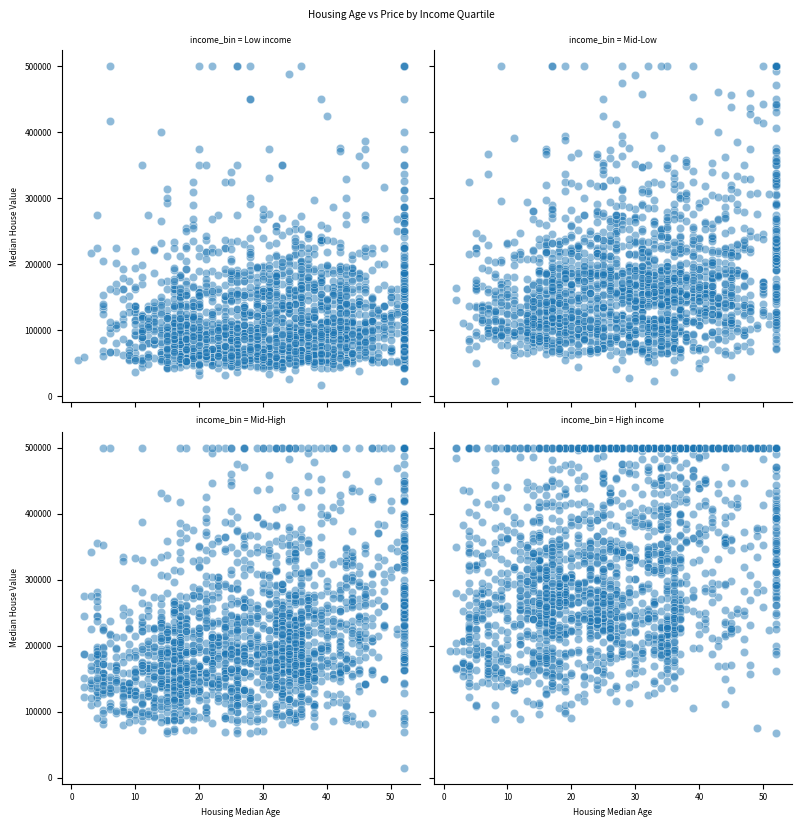

# 📊 [심층 분석] 소득 수준별 가격의 분산 구조와 주택 연령의 역할

소득 수준을 통제(Income Binning)했을 때, 주택 연령이 가격 분포에 미치는 비선형적 영향력을 분석합니다.

---

## 1. 분석의 전제: 소득이 통제된 상태에서의 조건부 현상
소득 수준에 따라 주택 가격의 '상한선'과 '분산의 크기'가 다르게 결정되며, 그 안에서 주택 연령(`age`)이 수행하는 역할이 변화합니다.

---

## 2. 소득 구간별 세부 분석

### 📉 Low Income (저소득 구간)
* **가격 구조:** 주택 가격 상단이 약 **200k 전후**에서 강력하게 제한됨.
* **연령의 역할:** `age`가 증가하더라도 가격 상단이 거의 움직이지 않으며, 분산도 매우 작음.
* **결론:** 소득 수준이 낮으면 주택이 아무리 오래되거나 특수한 이력이 있어도 고가 형성이 불가능함.

### 📈 Mid-Low Income (중저소득 구간)
* **가격 구조:** 가격 상단이 약 **300k**까지 확장됨.
* **연령의 역할:** `age` 증가와 함께 가격 분산이 약간 커지기 시작함.
* **결론:** `age`가 단독 요인으로 작동하기 시작하는 지점이나, 여전히 소득이 가격을 지배하는 구조임.

### 🚀 Mid-High Income (중고소득 구간)
* **가격 구조:** 가격 상단이 **400~500k**까지 열리며 고가 형성이 허용됨.
* **연령의 역할:** 특히 `age` 20~40 구간에서 고가가 밀집되는 경향을 보임.
* **특징:** 이 구간의 주택 연령은 '노후'가 아닌 **'성숙한 주거지'**를 의미하며, `age` 효과가 비선형적으로 나타남.

### 💎 High Income (고소득 구간)
* **가격 구조:** 전 연령대에서 고가 주택이 존재하며 분산이 매우 큼.
* **연령의 역할:** 특히 **52(데이터 상한값)** 지점에서 고가가 집중되는 현상이 뚜렷함.
* **특징:** 입지가 좋고 역사적 가치가 있는 오래된 주택들이 소득 기반 위에서 최고가를 형성함.

---

## 3. 종합 요약 및 통찰

| 소득 수준 | 가격 상한 (Cap) | 주택 연령(Age)의 영향력 | 분산 특징 |
| :--- | :--- | :--- | :--- |
| **Low** | ~200k | 거의 없음 (소득에 묶임) | 매우 작음 |
| **Mid-Low** | ~300k | 독립적 요인으로 작동 시작 | 약간 커짐 |
| **Mid-High** | ~500k | **비선형적 (20~40년형 선호)** | 큼 |
| **High** | Open (500k+) | **역사적/입지적 가치로 반영** | 매우 큼 |

### 📌 결론
고소득 지역에서는 **"오래된 집도 비쌀 수 있다"**는 명제가 성립하지만, 저소득 지역에서는 **"오래된 집은 소득의 한계 내에서만 가격이 결정된다"**는 상이한 메커니즘이 작동합니다.

# 미션 3: “로그/비선형 변환을 고민해 보자”
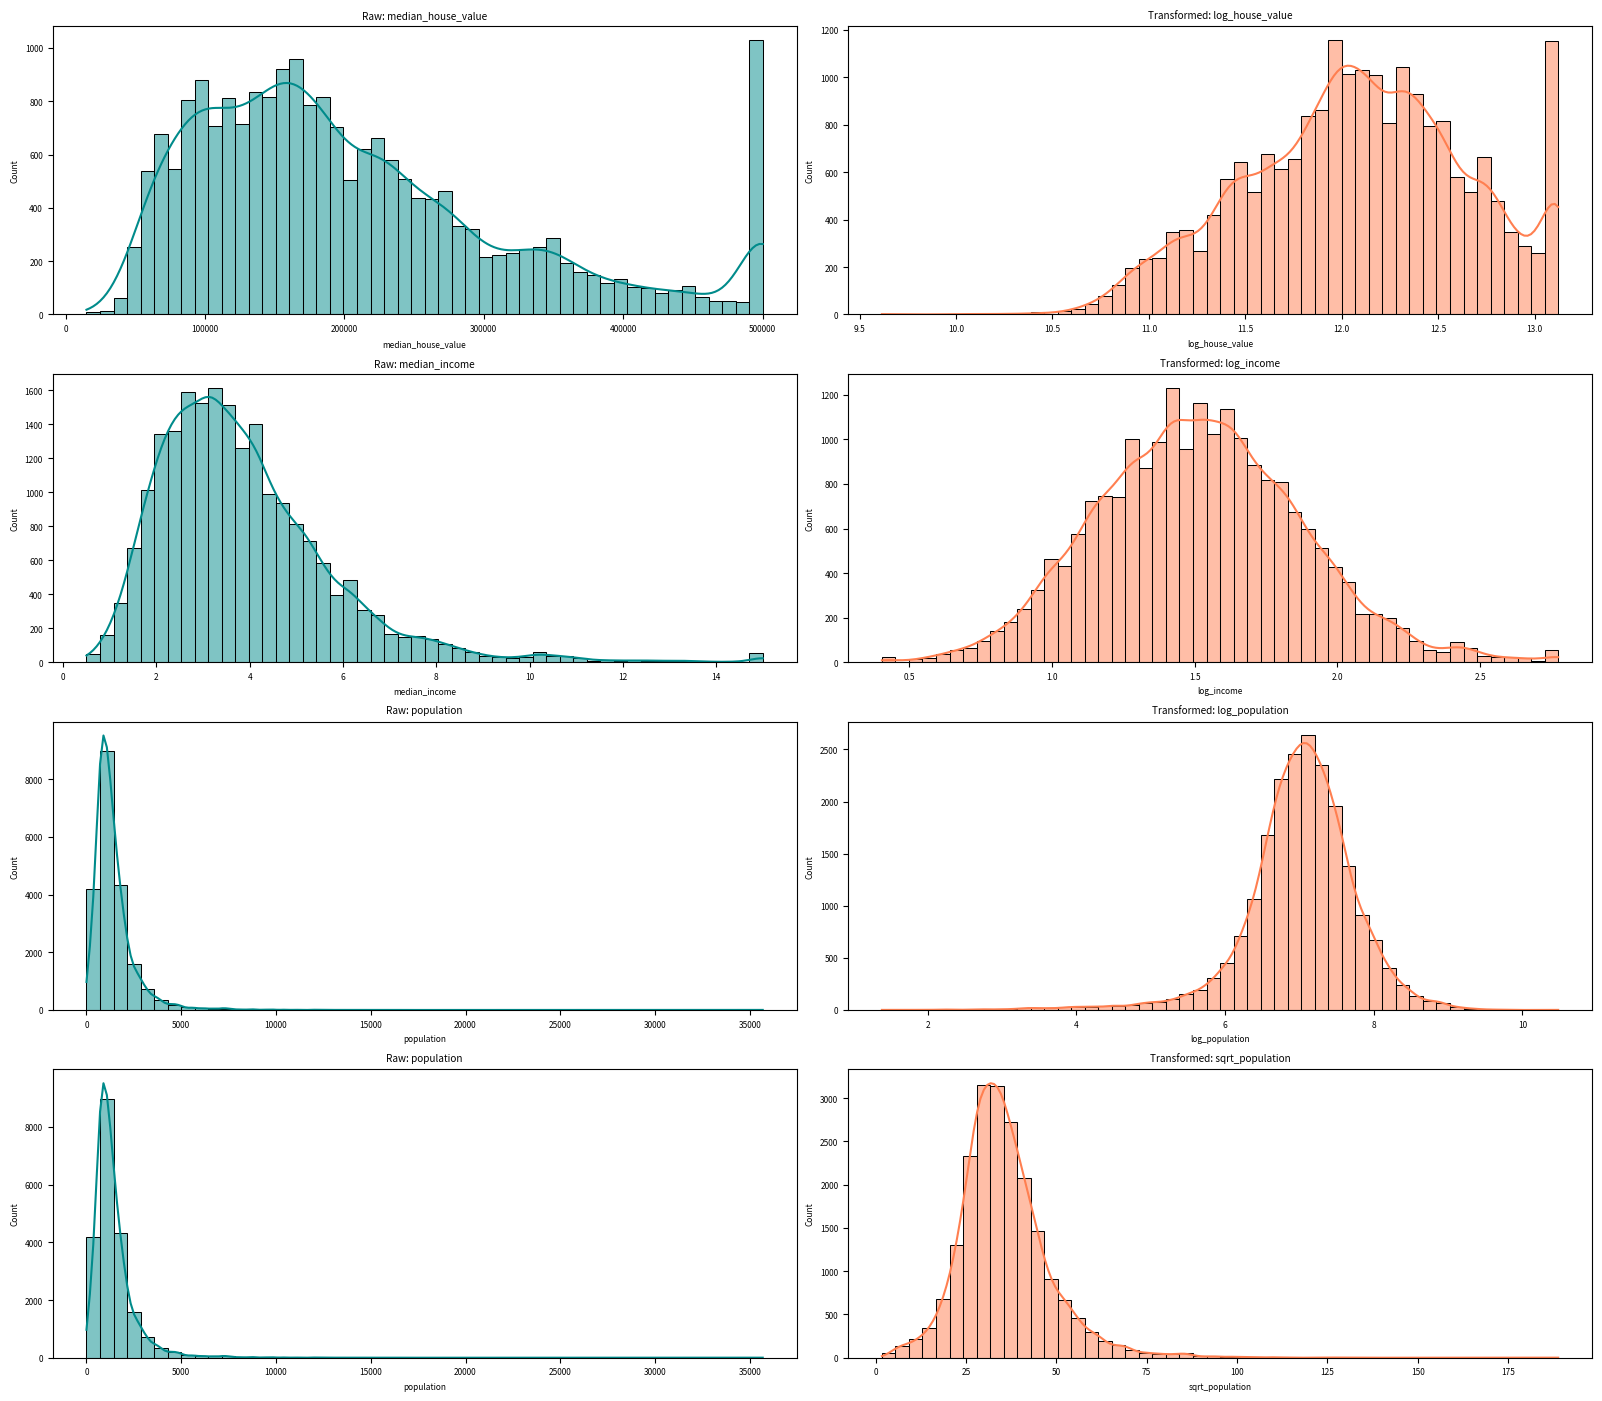

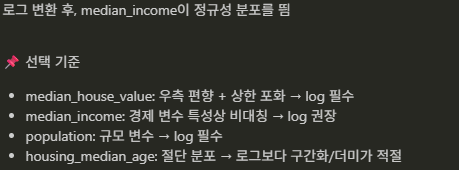




## 📝미션 4. “지리적 위치는 정말 중요할까?”위도(Latitude)와 경도(Longitude)를 활용한 지리적 시각화를 수행한다.<br>
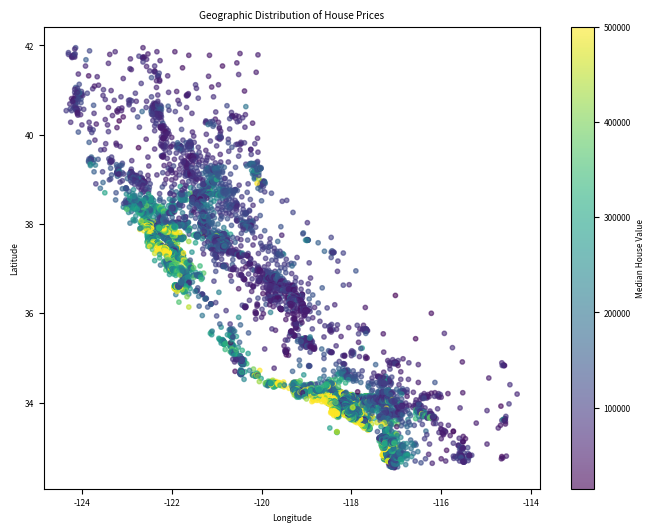<br>
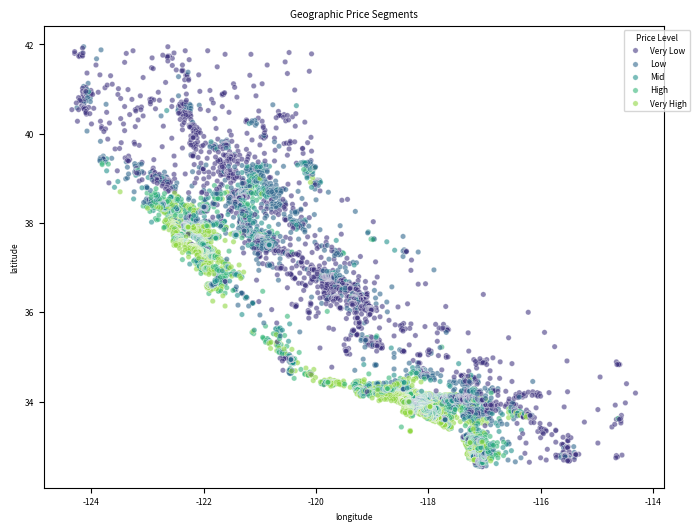<br>
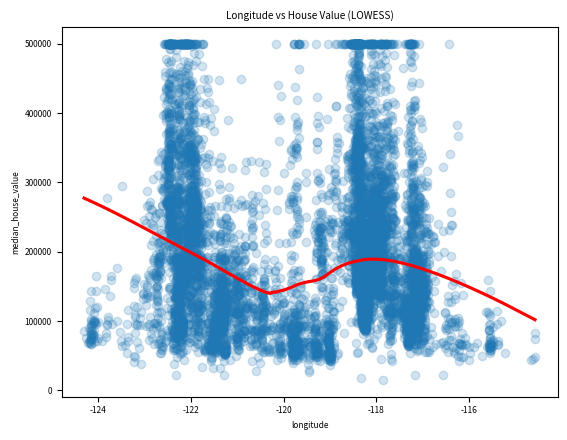<br>
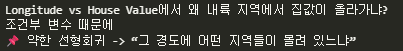<br>
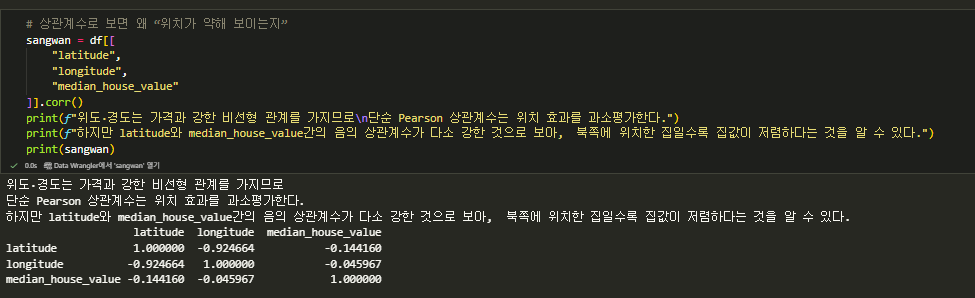<br>
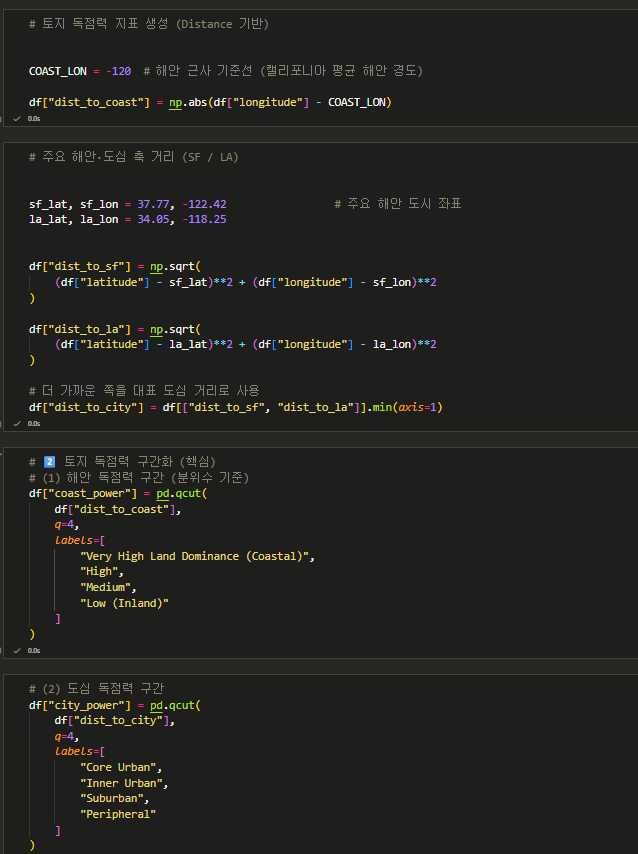<br>

# (1) 해안 독점력별 가격 분포
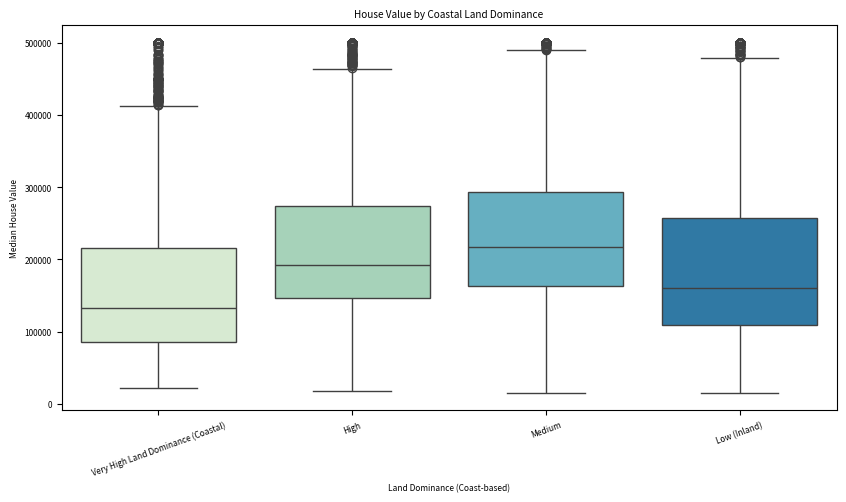
# 🌊 해안가 주택 가격의 역설: "가장 비싼데 왜 하단은 싸 보일까?"

해안 접근성(`Very High Land Dominance`)이 높은 그룹에서 저가 주택이 관찰되며 하단 사분위수(Q1)가 낮게 나타나는 원인을 분석합니다.

---

## 1. 제1차 원인: 입지의 양면성과 혼합 분포 (Mixture Distribution)
해안 접근성이라는 단일 변수 안에는 성격이 완전히 다른 두 집단이 공존합니다.

* **A. 초고가 해안 (Premium Coastal):**
    * **지역:** 샌프란시스코(SF), 말리부, 산타모니카 등.
    * **특징:** 토지 희소성 극대화, 고소득 수요 집중 → **최고가 상단 형성.**
* **B. 저가 해안 (Industrial/Rural Coastal):**
    * **지역:** 센트럴 밸리 인근, 낙후된 해안 소도시.
    * **특징:** 관광지가 아닌 산업·항만·농업 연계 지역 → **낮은 주거 수요 및 가격 형성.**

> **📌 핵심 통찰**
> 해안 접근성은 '부촌 여부'를 보장하지 않습니다. 이는 전형적인 **혼합 분포**의 특성으로, 물리적 거리와 경제적 가치가 반드시 비례하지 않음을 보여줍니다.

---

## 2. 제2차 원인: 거주 적합성(Livability)의 차이
"바다와 가깝다"는 물리적 사실이 반드시 "살기 좋은 동네"를 의미하지는 않습니다.

* **해안가에 공존하는 저가 요소:**
    * 오래되고 노후화된 주택 밀집 구역.
    * 저소득 어업 및 항만 노동자 중심의 주거지.
    * 관광 인프라가 전무한 비수기 지역.

---

## 3. 제3차 원인: 통계적 분산의 역설
분산의 크기가 사분위수(Q1)의 위치에 미치는 영향입니다.

* **Very High 그룹 (해안):**
    * 초고가와 저가가 공존하여 **분산이 가장 큼.**
    * 저가 해안 데이터가 포함되면서 하위 25% 지점인 **Q1이 급격히 하락.**
* **High / Medium 그룹 (내륙):**
    * 계획된 내륙 도시 위주로 구성되어 **분포가 균질함.**
    * 극단적인 저가가 적어 상대적으로 **Q1이 높게 유지됨.**

> **📊 통계적 성질**
> 이는 역설이 아니라, **"분산이 클수록 하위 경계값(Q1)은 더 낮게 내려갈 가능성이 크다"**는 통계적 원리를 충실히 따르는 현상입니다.

---

## 💡 분석 결론
해안가 데이터 해석 시 **단순 평균**을 사용하는 것은 위험합니다. 
해당 그룹의 **높은 분산과 이질성(Heterogeneity)**을 인지하고, '관광/부촌'과 '산업/낙후' 지역을 구분할 수 있는 추가 변수(예: 가구 소득 또는 위도/경도 기반 클러스터링)를 도입하는 것이 모델의 정확도를 높이는 핵심입니다.



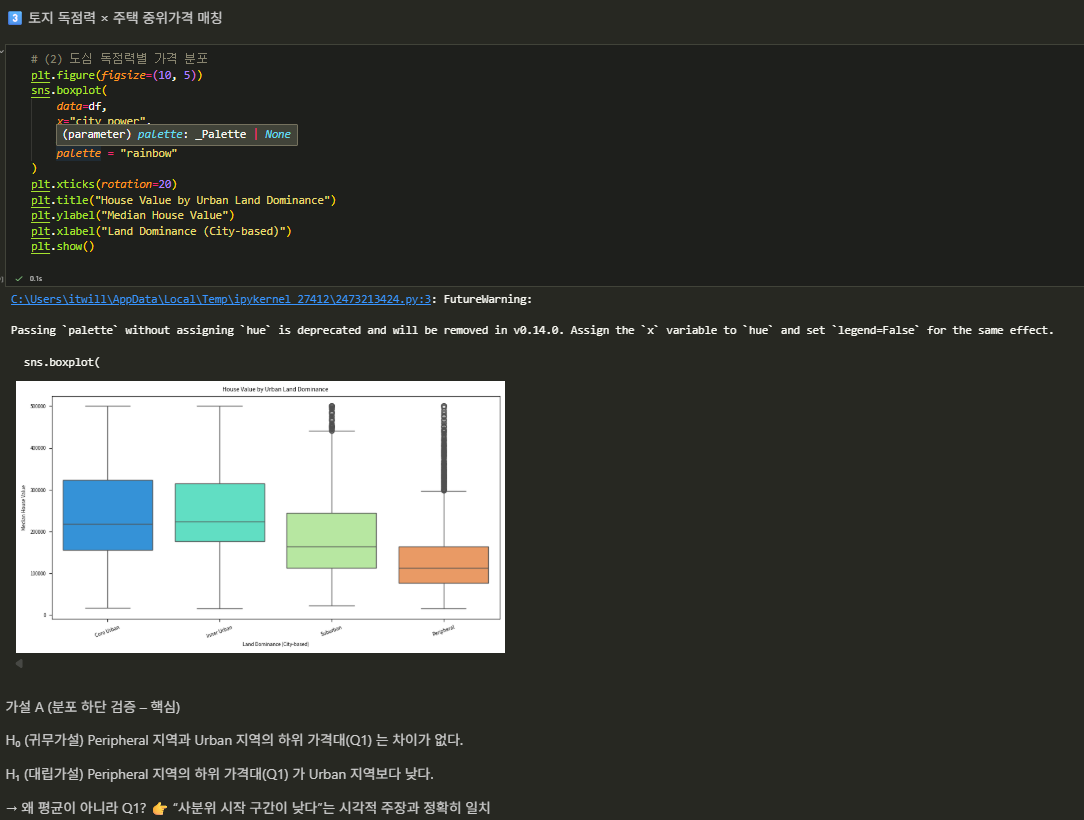

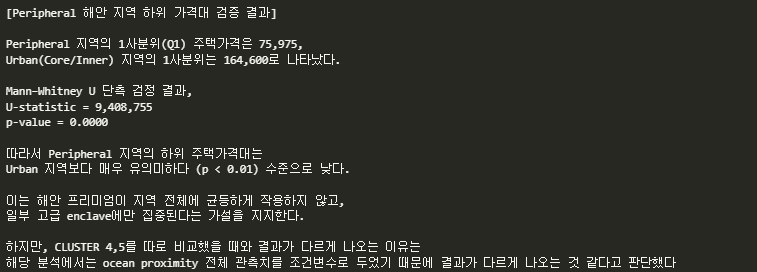

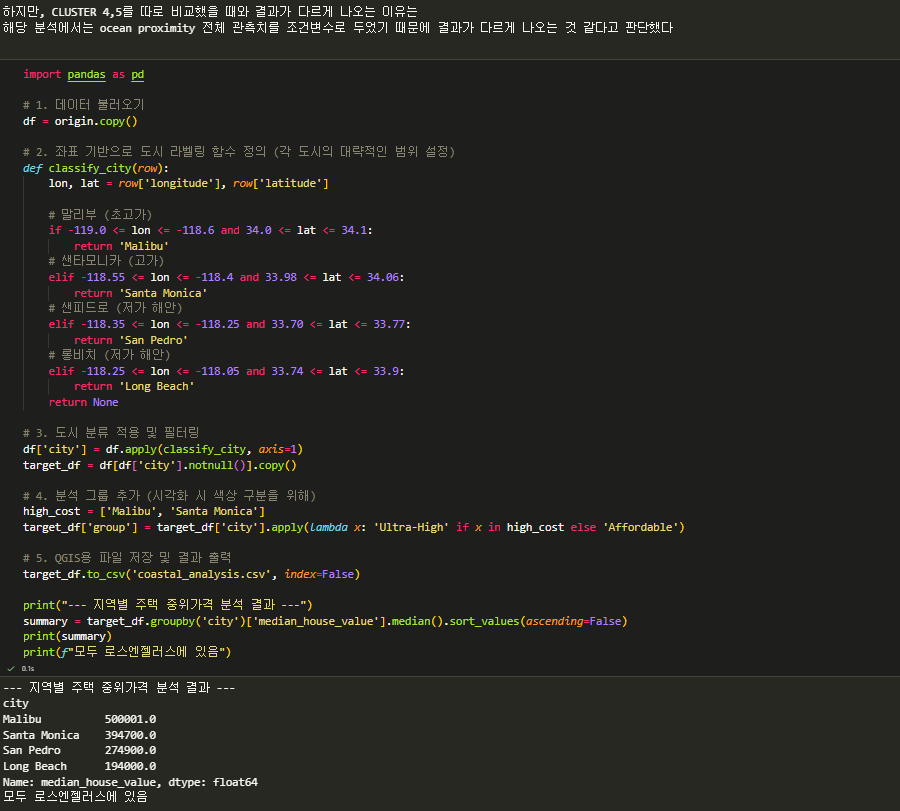

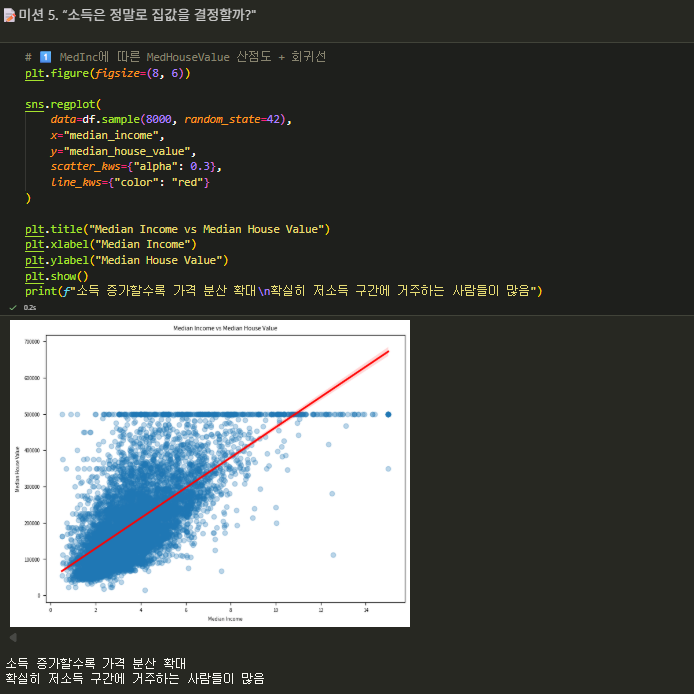<br>
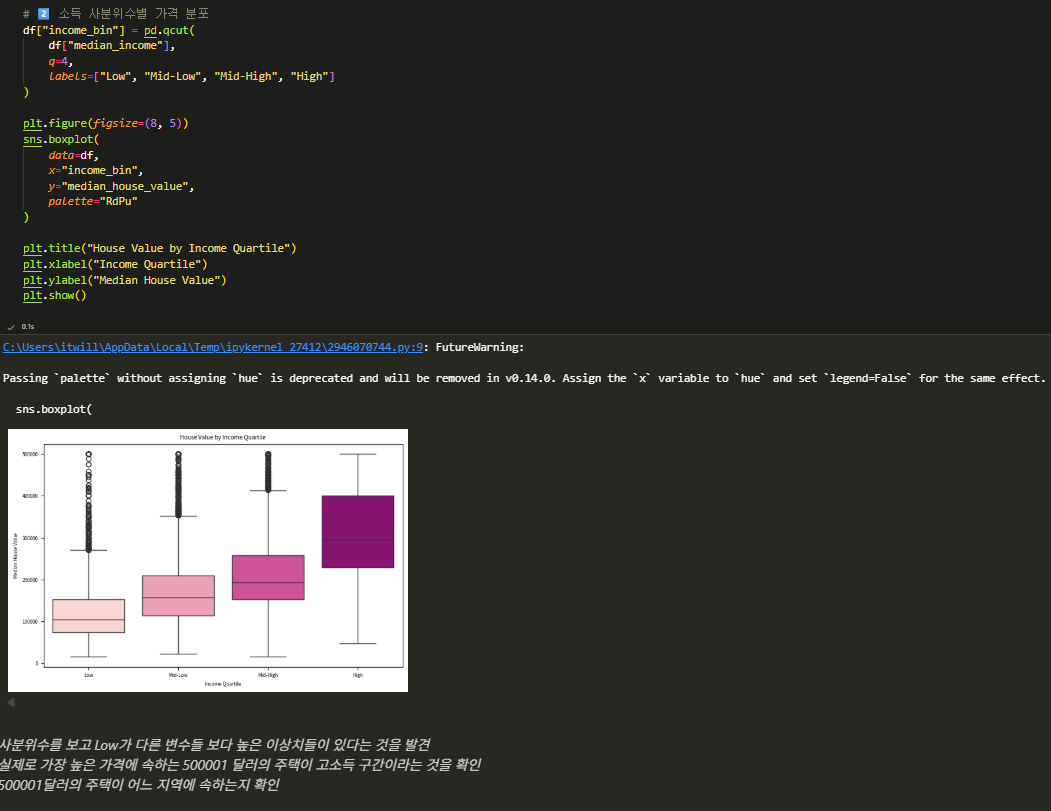<br>
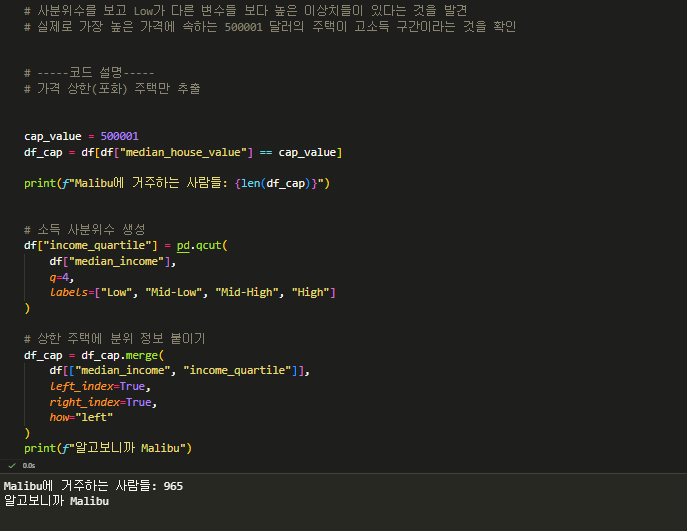<br>
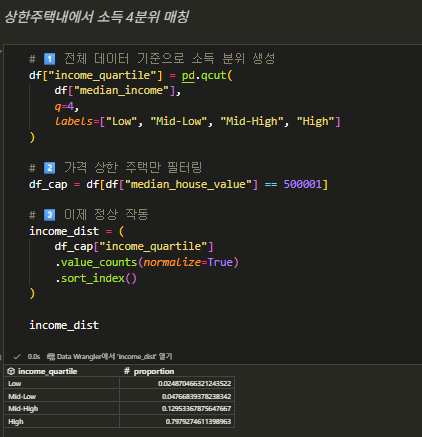<br>
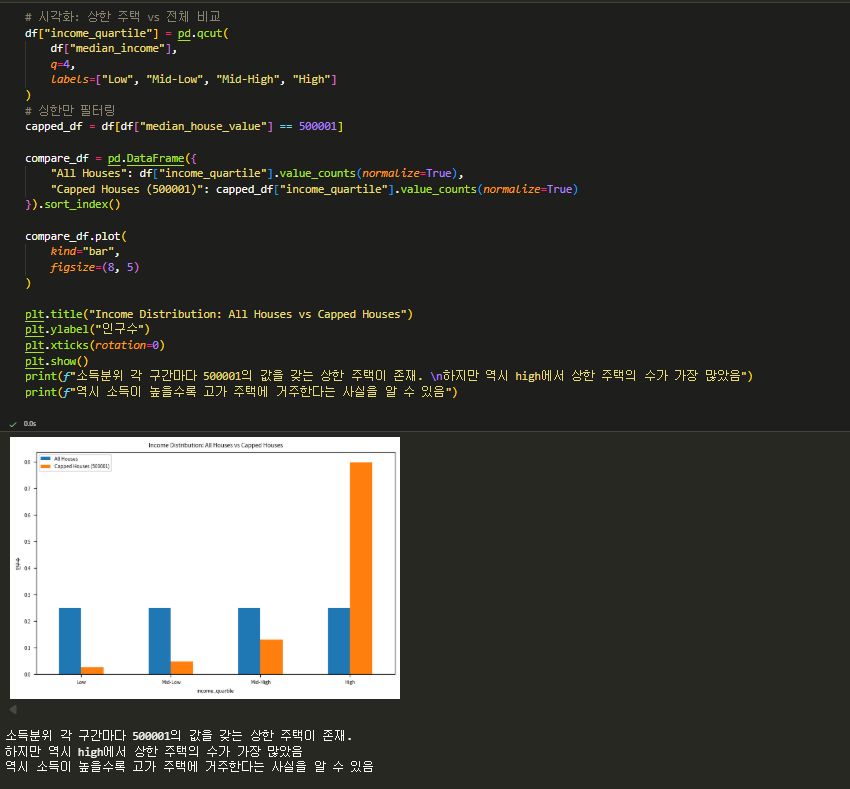<br>
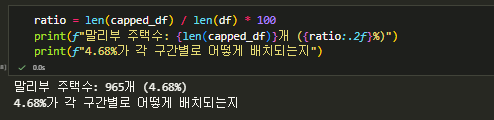<br>
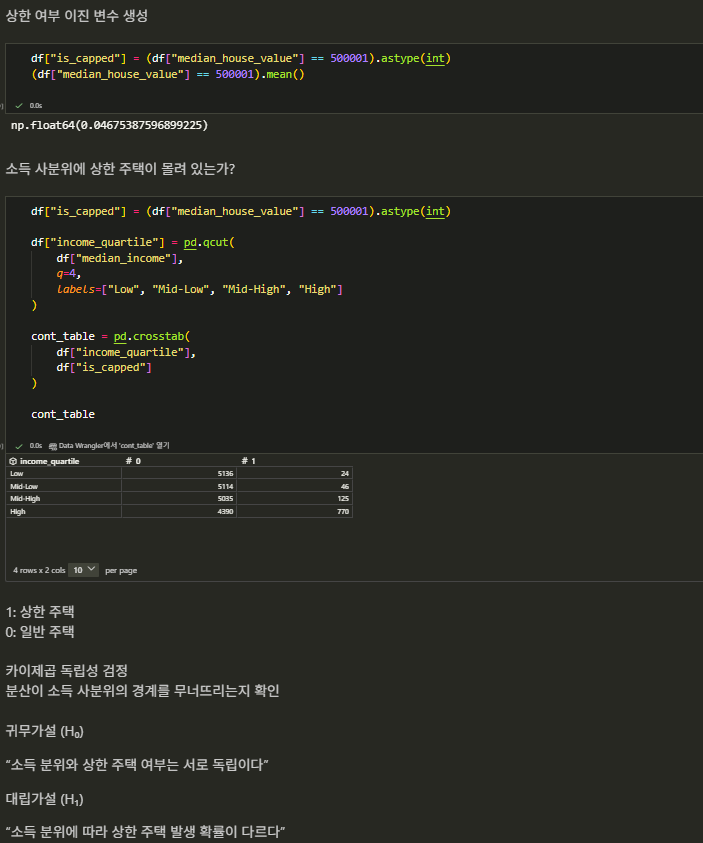<br>
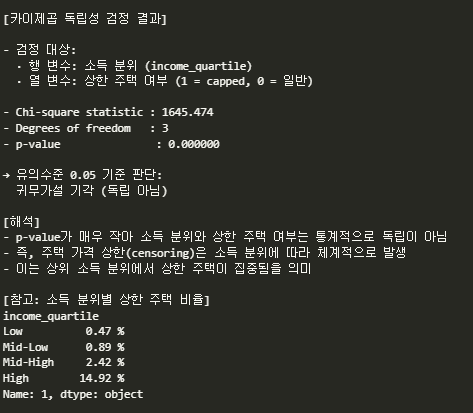<br>
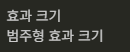<br>
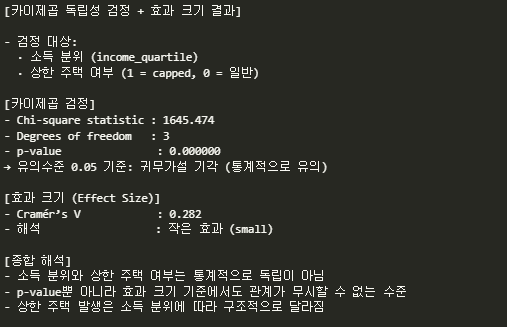<br>


 ## 📝 미션 7. “소득과 다른 특성은 독립적일까?”<br>
 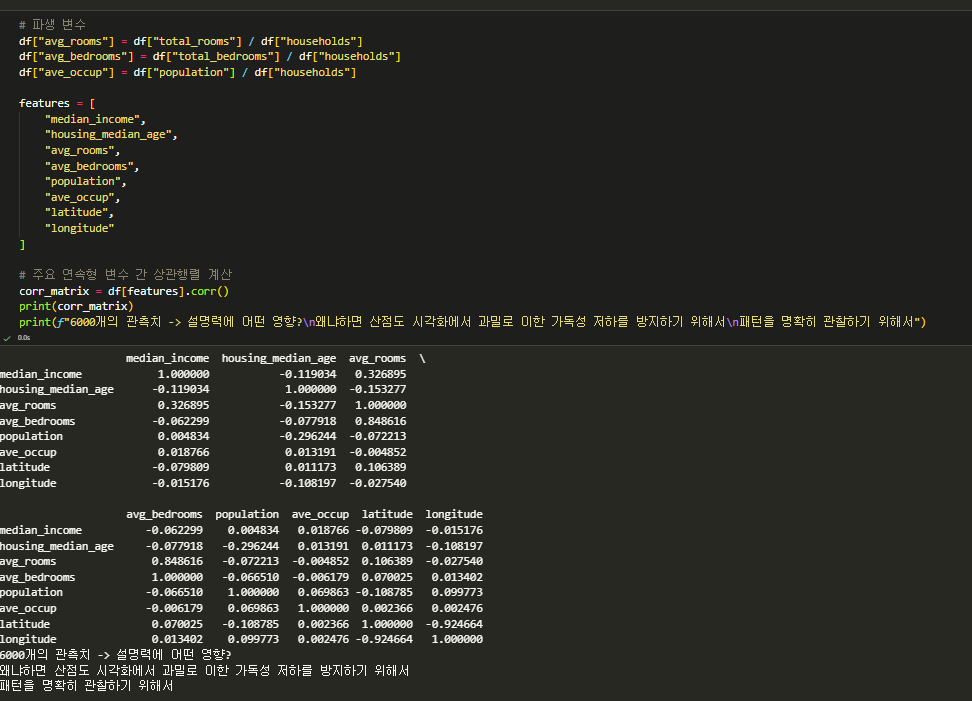<br>
 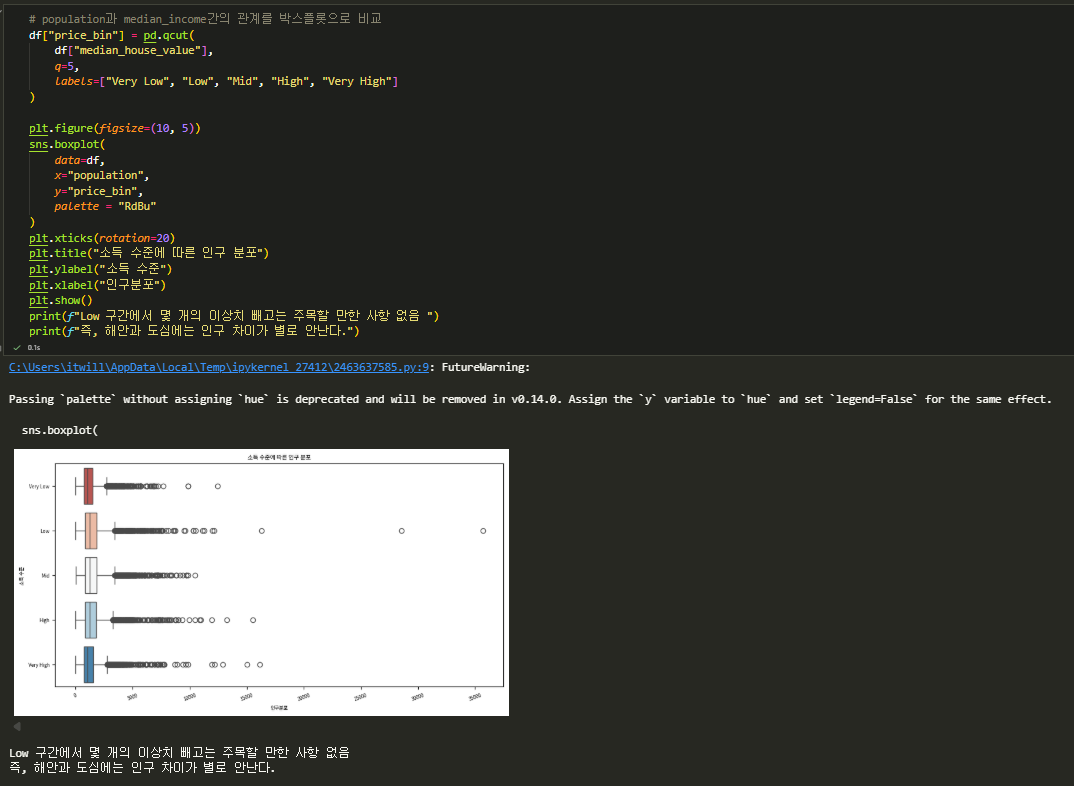<br>
 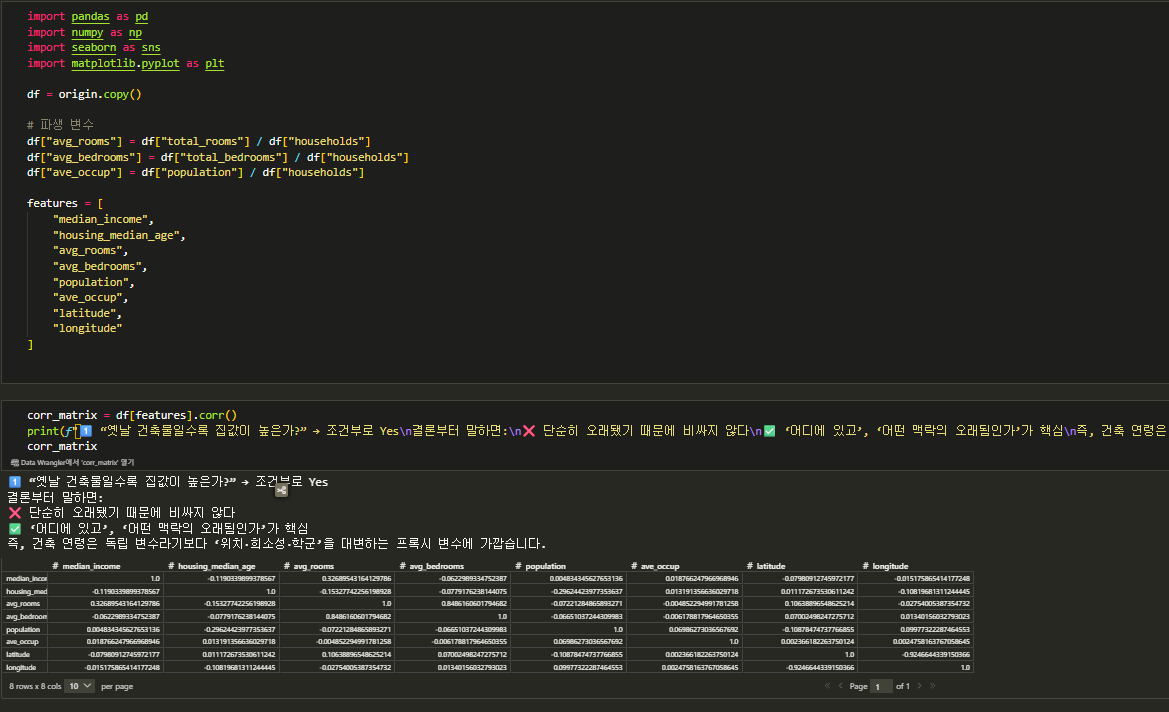<br>

 ✅ ② Robust 회귀 (이상치에 둔감)<br>
 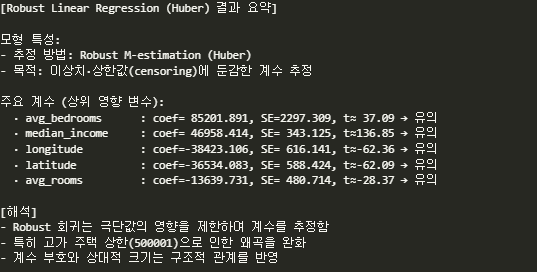<br>

## 📝 미션 12. “모형 진단과 개선”

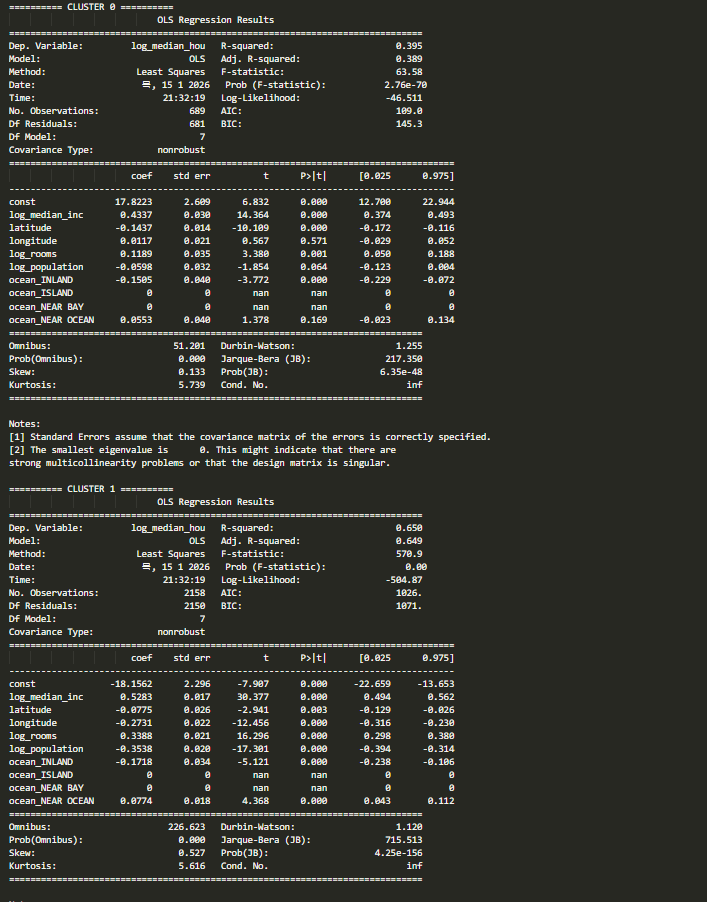<br>
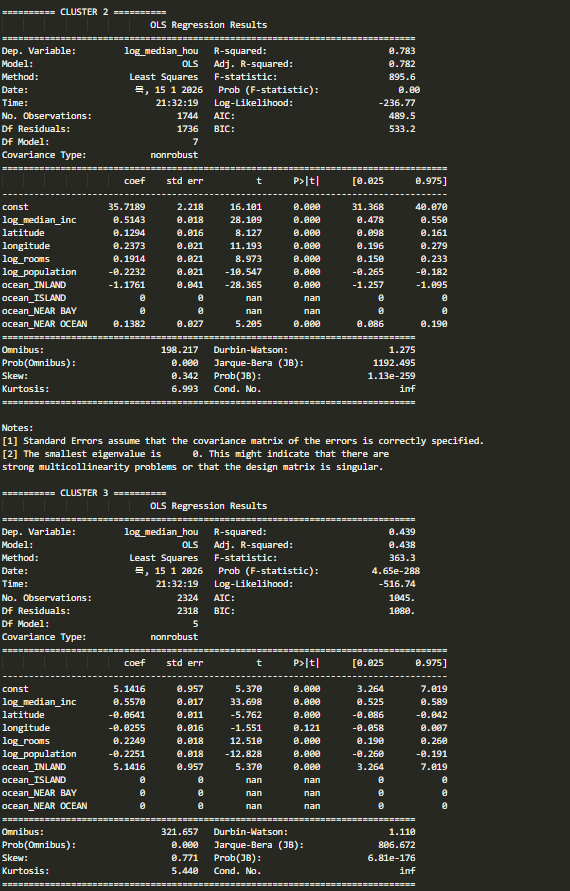<br>
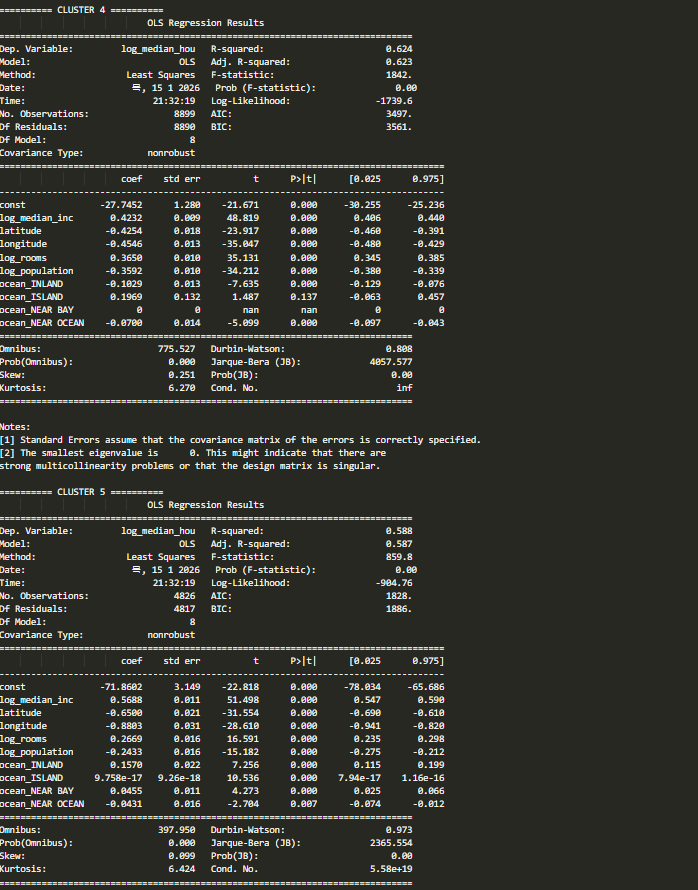<br>
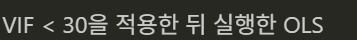<br>
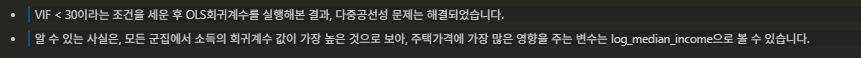

## 📝 미션 13. “같은 소득인데 왜 가격은 다를까?”<br>
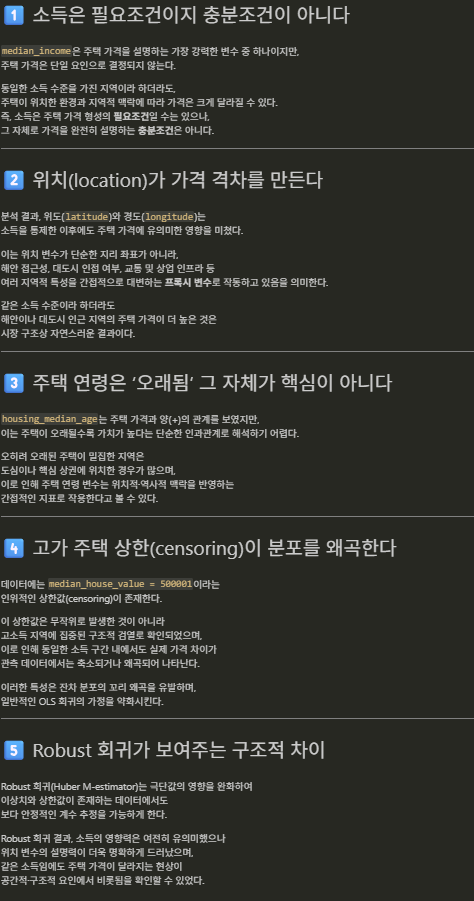